[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlos-argueta/factor-graphs-from-scratch/blob/main/modules/04-lie-groups/lesson.ipynb)

# Module 4 — Lie groups & on-manifold optimization

> **Goal.** Make the optimiser we built in M3 work for the variables that actually matter in robotics: **rotations and rigid-body poses**. A heading angle lives on a circle, not a line; a 3-D orientation lives on a curved 3-dimensional surface, not in $\mathbb{R}^3$. Feeding these to a vector least-squares solver produces silent, wrong answers at the wrap-around. The fix is to keep each unknown *on its manifold* and do the optimisation in a flat **tangent space** that touches it — the operators $\boxplus$ (**retract**) and $\boxminus$ (**local**). By the end we have `Pose2` and `Pose3` types, an on-manifold Gauss–Newton loop, and two working pose-graph optimisers (SE(2) and SE(3)) that close a loop the way real SLAM back-ends do.

This is the module that retires every "add $2\pi$ if the angle wrapped" hack. Those hacks are a symptom; the disease is optimising a curved quantity as if it were flat. Lie theory is the cure, and it turns out to cost only **two small operators** bolted onto the M3 engine:

$$\boxed{\;X \boxplus \xi \;=\; X\,\exp(\xi)\qquad\qquad Y \boxminus X \;=\; \log\!\big(X^{-1}Y\big)\;}$$

Everything else — the residuals, the Jacobians, the normal equations — is exactly M3. We just replace the vector update $x \leftarrow x + \delta$ with the manifold update $x \leftarrow x \boxplus \delta$.

### A refresher: what is a manifold?

A **manifold** is a space that is *curved when you look at the whole thing, but flat when you look up close*. The stock example is the surface of the Earth: it is a sphere, yet the patch of ground around you looks like a flat plane, and a flat street map is accurate enough to walk by even though it quietly ignores the planet's curvature. Two properties are all we need:

- **Locally flat.** Zoom in far enough on any one point and the manifold is indistinguishable from ordinary flat space $\mathbb{R}^n$. That flat approximation, pinned at a point, is the **tangent space** — the street map, the ground that looks level under your feet. Addition and subtraction make sense *there*.
- **Globally curved — it wraps.** Step back and the flatness fails: walk far enough "straight" on a sphere and you arrive back where you started. No single flat coordinate chart covers the whole surface without a **seam** — a line where the flat coordinates have to be cut and rejoined. Peel an orange and press the peel flat and it must tear somewhere; a flat world map splits the globe down one edge, so $+179°$ and $-179°$ longitude land at opposite sides of the sheet even though they are neighbours on the ground. That tear is exactly the $\pm\pi$ wrap-around that broke the heading angle in the box above.

**How this connects to the variables we estimate.** The unknowns in a robotics problem are *points on manifolds*, not free vectors in $\mathbb{R}^n$:

- a **heading angle** lives on a *circle* — one dimension, but it wraps at $\pm\pi$;
- a **3-D orientation** lives on a curved 3-dimensional surface — you cannot cover it with three independent angles without hitting the same kind of coordinate breakdown (here it is called *gimbal lock*);
- a **pose** (position *and* orientation) lives on a manifold called $SE(2)$ or $SE(3)$ — the *special Euclidean* groups, whose name §3 unpacks.

A bare **position** is the special easy case: $\mathbb{R}^2$ or $\mathbb{R}^3$ is itself a (flat, seamless) manifold, which is why M0–M3 could treat every unknown as a vector and get away with plain $+$ and $-$. The instant an *orientation* enters the state, the space curves, and those vector operations stop meaning what we assumed.

The plan for the whole module is just the two properties above, used deliberately: **do the optimisation in the flat tangent space** — where $+$, least squares, and Gauss–Newton work exactly as in M3 — then **map the small correction back onto the curved manifold** so the estimate never leaves it. Those two maps, *onto* the tangent space and *back*, are precisely the $\boxminus$ and $\boxplus$ in the box above. A **Lie group** — the subject of §2 — is the special (and, for us, ubiquitous) kind of manifold where those maps have clean closed forms, because the manifold is *also a group*: its points can be composed and inverted, like rotations and rigid motions.

In [1]:
import sys, pathlib, subprocess
import numpy as np

# --- Colab bootstrap -------------------------------------------------------
# On Google Colab the repository isn't present, so clone it once to make the
# course packages (`gaussian_filters`, `factorgraph`) importable.
REPO_URL = "https://github.com/carlos-argueta/factor-graphs-from-scratch.git"
if "google.colab" in sys.modules:
    repo = pathlib.Path("/content/factor-graphs-from-scratch")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo)], check=True)
    if str(repo / "src") not in sys.path:
        sys.path.insert(0, str(repo / "src"))

# --- Local: put the repo's src/ on the path (covers gaussian_filters + factorgraph)
def _add_src_to_path():
    here = pathlib.Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "src" / "factorgraph").exists():
            if str(base / "src") not in sys.path:
                sys.path.insert(0, str(base / "src"))
            return
_add_src_to_path()

np.set_printoptions(precision=5, suppress=True)

In [2]:
import matplotlib.pyplot as plt

# palette (light surface) + recessive chrome  — shared with M0/M1/M2/M3
BLUE, AQUA, VIOLET, RED = "#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

def _style(ax, title):
    ax.set_title(title, color=INK, fontsize=11, pad=8)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=8)

## 1 · Why angles break least squares

Everything in M0–M3 assumed the unknowns live in $\mathbb{R}^n$: to improve an estimate you add a correction, $x \leftarrow x + \delta$, and to compare two estimates you subtract, $x - y$. That is the *only* thing the Gauss–Newton normal equations know how to do.

Now put a **heading angle** $\theta$ in the state. Two facts break immediately:

- **Subtraction is wrong near the wrap.** The "error" between $\theta = 179°$ and $\theta = -179°$ is $2°$, not $358°$. A residual $\theta_i - \theta_j$ computed naively reports the $358°$ and the solver yanks the estimate the long way around the circle.
- **Averaging is wrong.** The mean of $350°$ and $10°$ is $0°$ (they straddle north), but the arithmetic mean is $180°$ — pointing exactly backwards.

The usual patch is an `angular_index`-style hack: keep a list of which state entries are angles, and after every subtraction call a `wrap_to_pi` that adds or subtracts $2\pi$ until the result lands in $(-\pi, \pi]$. It works for a single angle if you remember to apply it *everywhere* — in the residual, in the Jacobian, in the covariance update, in the state add. Miss one spot and you get a rare, data-dependent blow-up that only shows up when the robot happens to be pointing near $\pm\pi$. And it does not generalise: there is no "add $2\pi$" trick for a $3\times3$ rotation matrix. The cell below shows the failure concretely.

In [3]:
# The wrap-around, made concrete: naive vector operations on angles.
def wrap_to_pi(a):
    """The angular_index hack: fold an angle back into (-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

a, b = np.deg2rad(179.0), np.deg2rad(-179.0)
print("two headings 2 degrees apart (179 and -179):")
print(f"  naive difference a - b      = {np.rad2deg(a - b):8.2f} deg   (wrong: the long way round)")
print(f"  wrapped difference          = {np.rad2deg(wrap_to_pi(a - b)):8.2f} deg   (right: 2 deg)")

hs = np.deg2rad([350.0, 10.0])
naive_mean = np.rad2deg(hs.mean())
circ_mean  = np.rad2deg(np.arctan2(np.sin(hs).mean(), np.cos(hs).mean()))
print("\naveraging 350 and 10 degrees (they straddle north):")
print(f"  arithmetic mean             = {naive_mean:8.2f} deg   (wrong: points backwards)")
print(f"  circular mean               = {circ_mean:8.2f} deg   (right: 0 deg)")

# The hack is fragile because it must be applied in *every* formula. The rest of
# this module removes the need for it: we never subtract angles as numbers, and
# we never add corrections as numbers. We compose group elements and retract.
assert abs(abs(np.rad2deg(wrap_to_pi(a - b))) - 2.0) < 1e-9

two headings 2 degrees apart (179 and -179):
  naive difference a - b      =   358.00 deg   (wrong: the long way round)
  wrapped difference          =    -2.00 deg   (right: 2 deg)

averaging 350 and 10 degrees (they straddle north):
  arithmetic mean             =   180.00 deg   (wrong: points backwards)
  circular mean               =    -0.00 deg   (right: 0 deg)


## 2 · SO(2): the circle as a group

The set of 2-D rotations is $SO(2)$ — the $2\times2$ rotation matrices

$$R(\theta) = \begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix},\qquad R^\top R = I,\quad \det R = +1.$$

**What the name means.** $SO$ stands for **special orthogonal**, and both words are just the two properties on that second line. *Orthogonal* is $R^\top R = I$: the columns are unit-length and mutually perpendicular, so the transformation preserves all lengths and angles — the defining feature of a rotation. *Special* is $\det R = +1$: it excludes mirror reflections (which have $\det = -1$), leaving only proper rotations. So $SO(n)$ is the group of rotations of $n$-dimensional space; $SO(2)$ here, $SO(3)$ in §7.

Two rotations compose by *matrix multiplication* ($R(\alpha)R(\beta) = R(\alpha+\beta)$), every rotation has an inverse ($R^\top$), and there is an identity ($I$). Closure + associativity + identity + inverse = a **group**. It is also a smooth 1-dimensional surface (a circle) sitting inside the $2\times2$ matrices — a **Lie group**: a set that is both a group and a manifold, with the two structures compatible. *(If either term is hazy, **Appendix E** is a one-page refresher on groups and Lie groups — worth reading now if this is your first pass.)*

**Why the matrix and not the number?** Because the matrix composes without wrapping. $R(\theta)$ is identical for $\theta$ and $\theta + 2\pi$; the ambiguity that broke subtraction simply is not present in the matrix. We *store* the group element (here parametrised by $\theta$, later by a full matrix) and only ever use a raw number for a **small local correction**.

### 2.1 · exp and log — moving between the group and its tangent

Picture the group as the **unit circle** in the plane, with the identity $R(0)=I$ sitting at the point $(1,0)$. The line we care about is the **tangent line** that just grazes the circle at that identity point — geometrically, the vertical line $x=1$. It meets the circle at exactly one point (the identity) and pulls away from it everywhere else; a line that kisses a curve at a single point this way is what *tangent* means. The line is one-dimensional, so a single number $\theta$ says where you are on it: how far you have slid from the identity, with a sign for the two directions (up the line for $\theta>0$, down it for $\theta<0$). That coordinate line is the **tangent space** $\mathfrak{so}(2)$; for $SO(2)$ it is just the real axis of angles.

Two maps connect the line to the circle (the figure below draws them):

- $\exp:\ \theta \mapsto R(\theta)$ **wraps** the tangent line onto the group — a length $\theta$ measured up the line becomes an arc of angle $\theta$ swept around the circle (on the *unit* circle, arc length *is* angle).
- $\log:\ R \mapsto \theta$ **unrolls** a group element back onto the tangent line, choosing the representative in $(-\pi,\pi]$.

For $SO(2)$ these are elementary — $\exp$ builds the rotation matrix, $\log$ reads the angle back with `atan2` (which *is* the wrap, done once and for all, in one place). The payoff is conceptual: this same $\exp/\log$ pair, with richer formulas, is what makes $SO(3)$ and $SE(3)$ work.

> **Where the "real axis" comes from, algebraically.** The tangent space is the set of velocities $\dot R(0)$ of curves $R(t)$ that pass through the identity. Differentiate the constraint $R(t)^\top R(t)=I$ at $t=0$: it gives $\dot R(0)^\top + \dot R(0) = 0$, so $\dot R(0)$ must be **skew-symmetric** — and a $2\times2$ skew-symmetric matrix is $\begin{bmatrix}0 & -\theta\\ \theta & 0\end{bmatrix}$, a single free number $\theta$. That is *why* a planar rotation's tangent is one real number; and $\exp$ of that skew matrix is exactly $R(\theta)$. (The full derivation — including why $\exp$ of the skew matrix *sums* to $R(\theta)$, and how the same argument gives $\mathfrak{so}(3)\cong\mathbb{R}^3$ — is in **Appendix F**.)

In [4]:
# SO(2): store the rotation as its matrix; exp/log bridge to the tangent (an angle).
def so2_exp(theta):
    """Tangent angle -> rotation matrix (wraps the line onto the circle)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def so2_log(R):
    """Rotation matrix -> tangent angle in (-pi, pi] (atan2 = the wrap, done once)."""
    return np.arctan2(R[1, 0], R[0, 0])

# round-trips: log is the inverse of exp, and it resolves the 2*pi ambiguity.
for deg in [0.0, 30.0, 179.0, -179.0, 181.0, 359.0]:
    th = np.deg2rad(deg)
    R  = so2_exp(th)
    back = np.rad2deg(so2_log(R))
    print(f"theta = {deg:7.1f} deg  ->  R  ->  log(R) = {back:7.1f} deg")

# 181 deg and 359 deg come back as -179 and -1: the matrix never sees the wrap,
# and log always returns the *shortest* representative -- no hack required.
assert abs(so2_log(so2_exp(np.deg2rad(181.0))) - np.deg2rad(-179.0)) < 1e-9
assert np.allclose(so2_exp(0.3) @ so2_exp(0.4), so2_exp(0.7))   # composition adds angles

theta =     0.0 deg  ->  R  ->  log(R) =     0.0 deg
theta =    30.0 deg  ->  R  ->  log(R) =    30.0 deg
theta =   179.0 deg  ->  R  ->  log(R) =   179.0 deg
theta =  -179.0 deg  ->  R  ->  log(R) =  -179.0 deg
theta =   181.0 deg  ->  R  ->  log(R) =  -179.0 deg
theta =   359.0 deg  ->  R  ->  log(R) =    -1.0 deg


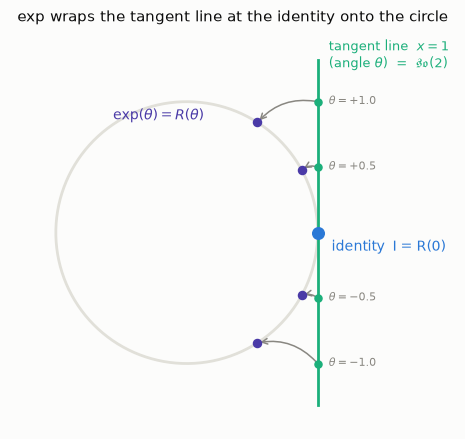

In [5]:
# Draw 2.1: the tangent line at the identity (x = 1), and exp wrapping it to the circle.
fig, ax = plt.subplots(figsize=(4.9, 4.9), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(t), np.sin(t), color=GRID, lw=2)                    # the group: the unit circle

# the identity at (1,0) and the tangent line there (vertical, x = 1), coordinate = theta
ax.plot([1, 1], [-1.32, 1.32], color=AQUA, lw=2)
ax.scatter(1, 0, color=BLUE, s=70, zorder=6)
ax.annotate("identity  I = R(0)", (1, 0), textcoords="offset points",
            xytext=(10, -13), color=BLUE, fontsize=10)
ax.annotate("tangent line  $x=1$\n(angle $\\theta$)  =  $\\mathfrak{so}(2)$", (1, 1.32),
            textcoords="offset points", xytext=(8, -6), color=AQUA, fontsize=9.5)

# slide up/down the line by a few thetas, then wrap each onto the circle with exp
for th in [-1.0, -0.5, 0.5, 1.0]:
    ax.scatter(1, th, color=AQUA, s=26, zorder=6)                  # a point theta on the tangent line
    p = np.array([np.cos(th), np.sin(th)])                         # exp(theta) = R(theta) on the circle
    ax.scatter(*p, color=VIOLET, s=34, zorder=6)
    ax.annotate("", xy=p, xytext=(1, th),
                arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1,
                                connectionstyle="arc3,rad=0.28"))
    ax.annotate(f"$\\theta={th:+.1f}$", (1, th), textcoords="offset points",
                xytext=(8, -2), color=MUTED, fontsize=8)
ax.annotate(r"$\exp(\theta)=R(\theta)$", (np.cos(1.0), np.sin(1.0)),
            textcoords="offset points", xytext=(-104, 2), color=VIOLET, fontsize=10)

ax.set_aspect("equal"); ax.axis("off")
ax.set_xlim(-1.35, 2.05); ax.set_ylim(-1.5, 1.55)
ax.set_title(r"exp wraps the tangent line at the identity onto the circle",
             color=INK, fontsize=11)
plt.tight_layout(); plt.show()

### 2.2 · $\boxplus$ and $\boxminus$: retract and local

Now define the two operators that replace $+$ and $-$ on the manifold. To nudge a rotation $R$ by a small tangent amount $\delta$, **retract**:

$$R \boxplus \delta \;=\; R\,\exp(\delta)\qquad\text{(rotate a bit more)}.$$

> **Which tangent space is $\delta$ in — and why "small"?** Good thing to pin down. There is only *one* tangent space we ever do arithmetic in: the Lie algebra $\mathfrak{so}(2)$ — the tangent *at the identity* from §2.1. $\delta$ is a vector there, and $\exp(\delta)$ turns it into a small rotation **near the identity**. Using $\exp(\delta)$ *by itself* would therefore move you near the identity — not what we want; we want to nudge $R$. Left-multiplying, $R\exp(\delta)$, re-plants that identity-anchored nudge at $R$: at $\delta=0$ you sit exactly on $R$, and growing $\delta$ slides you along the circle *away from $R$*. So $\delta$ is **read at the identity** (the single flat space the solver optimises in), while the motion it produces **happens at $R$** — the velocity of the curve $\delta\mapsto R\exp(\delta)$ at $\delta=0$ is the tangent line drawn at $R$ in the picture below. We never need a separate tangent space per point: the group is *homogeneous* (multiply by $R^{-1}$ and every point looks like the identity), so the identity's tangent space, carried over by multiplication, serves every $R$. As for **small** — in the solver $\delta$ is a *correction step*: the flat tangent is only a first-order stand-in for the curved group, so Gauss–Newton takes a small $\delta$, retracts, and re-anchors at the updated $R$ (the "tangent moves with us" of §4). For $SO(2)$/$SO(3)$, $\exp$ is in fact valid for *any* $\delta$; "small" describes how it is *used*, not a limit of the map.

To ask "what tangent vector takes me from $R$ to $S$?", take the **local** coordinates:

$$S \boxminus R \;=\; \log\!\big(R^{-1}S\big)\qquad\text{(the shortest turn from $R$ to $S$)}.$$

These are inverse to each other: $(R \boxplus \delta) \boxminus R = \delta$. They are the whole trick. Anywhere M0–M3 wrote $x + \delta$ we will write $x \boxplus \delta$; anywhere they wrote $y - x$ we will write $y \boxminus x$.

This is also the cleanest place to separate two things that *look* identical in 2-D but play completely different roles — a difference that hardens into a wall the moment you reach 3-D. The **global state** $\theta$ is your *absolute* orientation: a point that lives **on** the curved circle, and it wraps ($\theta$ and $\theta\pm2\pi$ are the same rotation). The **local nudge** $\delta$ is a *relative* step: it lives on the **flat tangent line**, is a plain number you can add and subtract freely, and never wraps. $\boxplus$ is the bridge between them — $\exp$ curls the flat step $\delta$ onto the circle and lands you at the updated state. The two panels below show exactly this: on the **left**, $\theta$ as an absolute point on the circle (the radial arrow, the swept angle); on the **right**, $\delta$ as a flat step along the tangent that $\exp$ wraps back onto the circle to reach $R\boxplus\delta = R(\theta+\delta)$.

> **Why the distinction matters beyond 2-D.** For a planar rotation, both $\theta$ and $\delta$ happen to be single numbers, so they look interchangeable — that is the trap. In 3-D the absolute orientation $R$ can no longer be written as a plain vector of angles without gimbal-lock seams; it *must* be stored as a $3\times3$ matrix (§7). The nudge $\delta$, however, stays a flat 3-vector. **State = matrix, nudge = vector** — you cannot add them with `+`, which is precisely why $\boxplus = R\exp(\delta)$ exists: it turns the flat vector $\delta$ into a small matrix and composes it onto $R$. So $\theta$ is *where you are on the map*; $\delta$ is *the direction of your next step*. The optimiser computes $\delta$ on the flat tangent, and $\boxplus$ curves that step back onto the manifold.

shortest turn from 170deg to -170deg: 20.0 deg


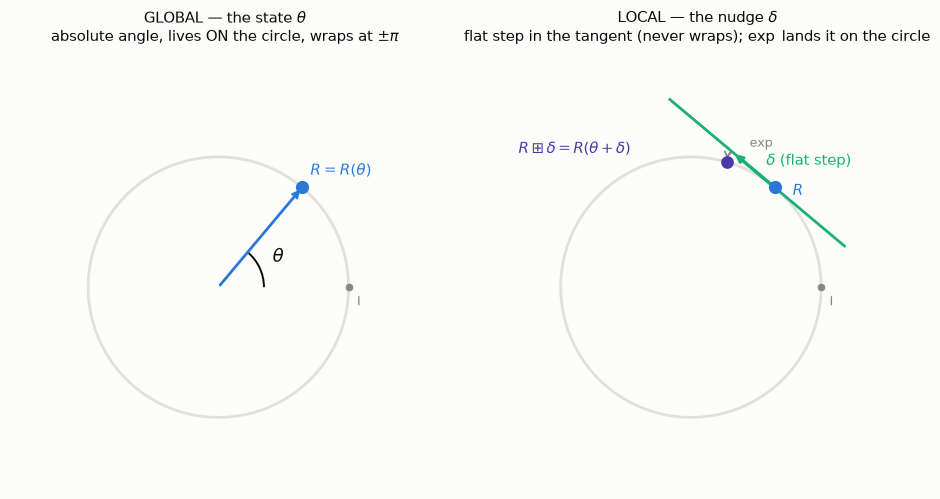

In [6]:
def so2_boxplus(R, delta):   # retract: nudge R by a tangent angle, stay on the circle
    return R @ so2_exp(delta)
def so2_boxminus(S, R):        # local: the shortest tangent angle from R to S
    return so2_log(R.T @ S)

# inverse relationship, and "shortest turn" even across the wrap
R = so2_exp(np.deg2rad(170.0))
d = np.deg2rad(20.0)
assert abs(so2_boxminus(so2_boxplus(R, d), R) - d) < 1e-12   # (R boxplus d) boxminus R = d
S = so2_exp(np.deg2rad(-170.0))                              # 20 deg past the wrap from R
print("shortest turn from 170deg to -170deg:", round(np.rad2deg(so2_boxminus(S, R)), 3), "deg")
assert abs(np.rad2deg(so2_boxminus(S, R)) - 20.0) < 1e-9    # 20, not -340

# picture: GLOBAL (theta, an absolute point on the circle) vs LOCAL (delta, a flat step).
from matplotlib.patches import Arc

th = np.deg2rad(50.0)                                  # an absolute orientation
dl = np.deg2rad(24.0)                                  # a (deliberately visible) local nudge
Rpt   = np.array([np.cos(th), np.sin(th)])
tang  = np.array([-np.sin(th), np.cos(th)])            # unit tangent at R (direction of +delta)
newpt = np.array([np.cos(th + dl), np.sin(th + dl)])   # R boxplus delta = R(theta + delta)
tstep = Rpt + dl * tang                                # the flat step delta, laid on the tangent line

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.9), facecolor="#fcfcfb")
tt = np.linspace(0, 2 * np.pi, 400)
for ax in axes:
    ax.set_facecolor("#fcfcfb")
    ax.plot(np.cos(tt), np.sin(tt), color=GRID, lw=2)
    ax.scatter(1, 0, color=MUTED, s=20, zorder=5)
    ax.annotate("I", (1, 0), textcoords="offset points", xytext=(6, -13), color=MUTED, fontsize=9)
    ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-1.6, 1.7); ax.set_ylim(-1.55, 1.82)

# --- GLOBAL: theta is an absolute point on the curved circle (and it wraps) ---
ax = axes[0]
ax.annotate("", xy=Rpt, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=BLUE, lw=2))
ax.add_patch(Arc((0, 0), 0.7, 0.7, angle=0, theta1=0, theta2=50, color=INK, lw=1.4))
ax.annotate(r"$\theta$", (0.46 * np.cos(th / 2), 0.46 * np.sin(th / 2)), color=INK, fontsize=13)
ax.scatter(*Rpt, color=BLUE, s=72, zorder=6)
ax.annotate(r"$R=R(\theta)$", Rpt, textcoords="offset points", xytext=(6, 9), color=BLUE, fontsize=11)
ax.set_title("GLOBAL — the state $\\theta$\nabsolute angle, lives ON the circle, wraps at $\\pm\\pi$",
             color=INK, fontsize=10.5)

# --- LOCAL: delta is a flat step on the tangent, wrapped onto the circle by exp ---
ax = axes[1]
ax.plot([Rpt[0] - 0.7 * tang[0], Rpt[0] + 1.05 * tang[0]],
        [Rpt[1] - 0.7 * tang[1], Rpt[1] + 1.05 * tang[1]], color=AQUA, lw=2)     # flat tangent "ruler"
ax.annotate("", xy=tstep, xytext=Rpt, arrowprops=dict(arrowstyle="->", color=AQUA, lw=2.4))
ax.annotate(r"$\delta$ (flat step)", Rpt + 0.5 * (tstep - Rpt), textcoords="offset points",
            xytext=(9, 3), color=AQUA, fontsize=10.5)                            # label on the step, not its tip
ax.annotate("", xy=newpt, xytext=tstep,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.3, connectionstyle="arc3,rad=0.4"))
ax.annotate(r"$\exp$", tstep, textcoords="offset points", xytext=(12, 4), color=MUTED, fontsize=9)
ax.scatter(*Rpt, color=BLUE, s=72, zorder=6)
ax.scatter(*newpt, color=VIOLET, s=66, zorder=6)
ax.annotate(r"$R$", Rpt, textcoords="offset points", xytext=(13, -6), color=BLUE, fontsize=11)
ax.annotate(r"$R\boxplus\delta=R(\theta+\delta)$", newpt, textcoords="offset points",
            xytext=(-150, 6), color=VIOLET, fontsize=10.5)
ax.set_title("LOCAL — the nudge $\\delta$\nflat step in the tangent (never wraps); $\\exp$ lands it on the circle",
             color=INK, fontsize=10.5)

plt.tight_layout(); plt.show()

## 3 · SE(2): rigid-body poses in the plane

A robot in the plane has a **pose**: a position $(x,y)$ and a heading $\theta$. Stacking them as $(x,y,\theta)\in\mathbb{R}^3$ is exactly the mistake from §1 — the $\theta$ slot wraps. The right home is $SE(2)$ — the **special Euclidean** group. The name follows the same pattern as $SO$: it is the group of *rigid motions* of Euclidean space — a rotation (the special-orthogonal part from §2) combined with a translation — i.e. every way to reposition a rigid body without stretching, shearing, or mirror-flipping it. $SE(2)$ is the planar case ($SE(3)$, the spatial one, is §8). We represent it as a $3\times3$ homogeneous matrix

$$T = \begin{bmatrix} R(\theta) & t \\ 0 & 1 \end{bmatrix},\qquad R(\theta)\in SO(2),\ \ t=\begin{bmatrix}x\\y\end{bmatrix}.$$

These matrices **compose** (matrix product), **invert**, and **act on points** — and reading those three operations correctly, without losing track of *which frame* each pose is expressed in, is where poses usually trip people up. We pin the rules down now, before adding the tangent space.


### 3.1 · Reading and composing a pose

Before we differentiate poses, we should be able to *read* them. One notational habit fixes almost all of the confusion: tag every pose with the two frames it relates, writing $^{w}T_{b}$ for **"frame $b$ expressed in world $w$."** Read it right-to-left as *"$b$ relative to $w$"* — the trailing subscript is the frame being described, the leading superscript is the frame you are describing it *in*.

A single pose is two things at once:

- **a description** — where frame $b$'s origin and axes sit, as seen from $w$ (they are literally the columns of the matrix); and
- **a transform** — the map that takes a point written in $b$'s coordinates and returns it in $w$'s: $\;^{w}p = {}^{w}T_{b}\,{}^{b}p$.

It is the *same* matrix; which role it plays is just which side you multiply on.

**Composition — inner frames cancel.** Chain two poses by matching the inner labels:

$$^{w}T_{c} \;=\; {}^{w}T_{b}\;{}^{b}T_{c}.$$

The inner $b$'s meet and cancel, leaving *"$c$ in $w$."* Read the product right-to-left: take $c$ as described in $b$, then re-express $b$ in $w$. This is the bookkeeping behind the informal *"do $^{b}T_{c}$ in $b$'s frame"* — with the labels lined up, you can never get the order backwards. And **which** frame a multiply acts in is decided purely by the side:

> **Left vs right — global vs local.** *Left*-multiplying by a pose acts in the fixed **world** frame; *right*-multiplying acts in the moving **body** frame. It is the very same left/right split as the right-perturbation convention $X\boxplus\xi = X\exp(\xi)$ from §2.2 — a nudge applied on the right is felt in the body's own frame. Because matrices do not commute, the two orders genuinely differ; §5's **adjoint** is exactly the gadget that converts a body-frame twist into the equivalent world-frame one.

**Inverse — swap the labels.** Undoing a pose flips super- and subscript:

$$(^{w}T_{b})^{-1} = {}^{b}T_{w}.$$

If $^{w}T_{b}$ is "where $b$ sits, seen from the world," its inverse is **"where the world's origin sits, seen from $b$"** — the same rigid relationship, viewed from the other frame. That is the whole meaning of `Pose2.inverse`.

**`between` — one inverse and one product.** "Where is $b$ from $a$'s point of view?" Route through the world and let the inner frames cancel:

$$^{a}T_{b} = {}^{a}T_{w}\,{}^{w}T_{b} = (^{w}T_{a})^{-1}\,{}^{w}T_{b}.$$

This is exactly `a.between(b)` in the `Pose2` type below — and, as §5 will show, it is the quantity a `BetweenFactor` compares against its measurement.


In [7]:
# Reading poses at the matrix level -- no Pose2 yet, just 3x3 homogeneous matrices.
# Convention: T_wa reads "frame a expressed in world w".
def T_of(x, y, deg):                       # build a homogeneous pose from (x, y, heading)
    th = np.deg2rad(deg)
    c, s = np.cos(th), np.sin(th)
    return np.array([[c, -s, x],
                     [s,  c, y],
                     [0,  0, 1]])

T_wa = T_of(1.0, 2.0, 30.0)                # frame a, expressed in the world
T_ab = T_of(0.5, 0.0, 40.0)                # frame b, expressed in a's frame

# (1) Composition: the inner a's cancel  ->  ^w T_b = ^w T_a  ^a T_b  (b in the world).
T_wb = T_wa @ T_ab
print("b in world:  x=%.3f  y=%.3f  th=%.1f deg"
      % (T_wb[0, 2], T_wb[1, 2], np.rad2deg(np.arctan2(T_wb[1, 0], T_wb[0, 0]))))

# (2) A pose acts on a point: b's origin, pushed into the world, is just b's translation.
p_b = np.array([0.0, 0.0, 1.0])            # b's origin in b-coordinates (homogeneous)
p_w = T_wb @ p_b
assert np.allclose(p_w[:2], T_wb[:2, 2])

# (3) Inverse swaps the labels: ^a T_w = (^w T_a)^-1 = "the world origin, seen from a".
world_origin_in_a = np.linalg.inv(T_wa) @ np.array([0.0, 0.0, 1.0])
print("world origin, seen from a:", np.round(world_origin_in_a[:2], 3))

# (4) between: b as seen from a, routed through the world -- recovers the T_ab we built.
T_ab_check = np.linalg.inv(T_wa) @ T_wb    # ^a T_b = (^w T_a)^-1  ^w T_b  (inner w's cancel)
assert np.allclose(T_ab_check, T_ab)
print("between(a, b) recovers b-in-a:", np.allclose(T_ab_check, T_ab))

b in world:  x=1.433  y=2.250  th=70.0 deg
world origin, seen from a: [-1.866 -1.232]
between(a, b) recovers b-in-a: True


### 3.2 · The tangent space and the twist

The tangent space of $SE(2)$ is 3-dimensional: a **twist** $\xi = (v_x, v_y, \omega)$ — a translational velocity plus an angular velocity. The exponential map is no longer "build a rotation and drop in the translation": because the frame is *rotating while it translates*, the translation part passes through a matrix $V(\omega)$ (it reduces to the identity as $\omega\to0$):

$$\exp\!\begin{pmatrix}v\\\omega\end{pmatrix} = \begin{bmatrix} R(\omega) & V(\omega)\,v \\ 0 & 1\end{bmatrix},\qquad V(\omega) = \frac{1}{\omega}\begin{bmatrix}\sin\omega & -(1-\cos\omega)\\ 1-\cos\omega & \sin\omega\end{bmatrix}.$$

$\log$ inverts it: read $\omega$ off the rotation block, then recover $v = V(\omega)^{-1} t$. The $V$ matrix is the part people forget when they "just stack $(x,y,\theta)$" — and it is exactly what makes retraction follow the curved path a moving robot actually takes. (Derivation and the small-angle Taylor forms are in **Appendix A**.)

In [8]:
# SE(2): a pose as a 3x3 homogeneous matrix, with the group operations and exp/log.
def _V_se2(w):
    """The SE(2) left-Jacobian block; -> I as w -> 0 (Taylor guard near 0)."""
    if abs(w) < 1e-8:
        A = 1.0 - w * w / 6.0            # sin(w)/w
        B = w / 2.0 - w**3 / 24.0        # (1 - cos w)/w
    else:
        A = np.sin(w) / w
        B = (1.0 - np.cos(w)) / w
    return np.array([[A, -B], [B, A]])

def se2_exp(xi):
    """Twist (vx, vy, omega) -> SE(2) matrix."""
    v, w = np.asarray(xi[:2], float), float(xi[2])
    T = np.eye(3)
    T[:2, :2] = so2_exp(w)
    T[:2, 2] = _V_se2(w) @ v
    return T

def se2_log(T):
    """SE(2) matrix -> twist (vx, vy, omega)."""
    w = so2_log(T[:2, :2])
    v = np.linalg.solve(_V_se2(w), T[:2, 2])
    return np.array([v[0], v[1], w])

# exp/log round-trip, including a large rotation
xi = np.array([0.4, -0.2, 2.7])
assert np.allclose(se2_log(se2_exp(xi)), xi, atol=1e-9)
print("twist -> exp -> log round-trip ok:", np.round(se2_log(se2_exp(xi)), 6))

twist -> exp -> log round-trip ok: [ 0.4 -0.2  2.7]


### 3.3 · A `Pose2` type

We wrap the matrix in a small class so the algebra reads like the geometry. It carries exactly the operations a factor needs: `compose` (the group product), `inverse`, `between` (the relative pose $T_a^{-1}T_b$, i.e. "$b$ as seen from $a$"), and the two manifold operators `retract` ($\boxplus$) and `local` ($\boxminus$). The `dof = 3` attribute tells the engine how many tangent dimensions this variable contributes — the only thing the solver needs to know to size the normal equations.

In [9]:
class Pose2:
    """A planar rigid pose (x, y, theta) stored as a 3x3 homogeneous matrix."""
    dof = 3
    def __init__(self, x=0.0, y=0.0, theta=0.0, T=None):
        if T is not None:
            self.T = np.asarray(T, float)
        else:
            self.T = np.eye(3)
            self.T[:2, :2] = so2_exp(theta)
            self.T[:2, 2] = [x, y]
    # readable accessors
    @property
    def x(self):     return self.T[0, 2]
    @property
    def y(self):     return self.T[1, 2]
    @property
    def theta(self): return so2_log(self.T[:2, :2])
    def xytheta(self):  return np.array([self.x, self.y, self.theta])
    # group operations
    def compose(self, other):  return Pose2(T=self.T @ other.T)
    def inverse(self):         return Pose2(T=np.linalg.inv(self.T))
    def between(self, other):  return Pose2(T=np.linalg.inv(self.T) @ other.T)  # this^{-1} * other
    # manifold operations  (right-perturbation convention)
    def retract(self, xi):     return Pose2(T=self.T @ se2_exp(xi))             # X boxplus xi
    def local(self, other):    return se2_log(np.linalg.inv(self.T) @ other.T)  # other boxminus X
    def __repr__(self):
        return f"Pose2(x={self.x:.3f}, y={self.y:.3f}, theta={np.rad2deg(self.theta):.1f}deg)"

# sanity: compose/inverse round-trips, and between is consistent with compose
A = Pose2(1.0, 2.0, np.deg2rad(30.0))
B = Pose2(2.5, 0.5, np.deg2rad(-80.0))
assert np.allclose(A.compose(A.inverse()).T, np.eye(3), atol=1e-12)
assert np.allclose(A.compose(A.between(B)).T, B.T, atol=1e-12)   # A * (A^-1 B) = B
# retract then local recovers the tangent step (boxplus/boxminus are inverse)
xi = np.array([0.1, -0.05, 0.2])
assert np.allclose(A.local(A.retract(xi)), xi, atol=1e-9)
print("Pose2 algebra ok. A between B =", A.between(B))

Pose2 algebra ok. A between B = Pose2(x=0.549, y=-2.049, theta=-110.0deg)


## 4 · On-manifold Gauss–Newton

Here is the entire idea of the module in one substitution. M1's Gauss–Newton was:

1. linearise: $r,\ J$ at the current estimate $x$,
2. solve the normal equations $J^\top J\,\delta = -J^\top r$,
3. update $x \leftarrow x + \delta$, repeat.

On a manifold, steps 1–2 are **unchanged** — the residual $r$ already lives in a flat vector space (it is a $\boxminus$ of two measurements), and we *define* the Jacobian columns as the derivative of $r$ with respect to a tangent perturbation of each variable. Only step 3 changes:

$$x \leftarrow x \boxplus \delta \qquad\text{instead of}\qquad x \leftarrow x + \delta.$$

The increment $\delta$ is computed in the tangent space at the current $x$; retraction maps it back onto the manifold; then we re-linearise at the new point (the tangent space has moved with us). That is why Gauss–Newton *iterates* here even for problems that were one-shot in M3: each step optimises a fresh local linear model of a curved problem.


### 4.1 · Numerical derivatives (finite differences)

The engine needs the derivative of each factor's error — its Jacobian — but we would like to *never hand-derive one*. There is a classical trick for getting a derivative from nothing but the ability to **evaluate the function**, and since we are about to lean on it, here it is from the start.

Begin with the definition of a derivative as a limit:

$$f'(x) \;=\; \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.$$

If we simply *stop taking the limit* and plug in a small but finite step $h=\epsilon$, we get an approximation — a **finite difference**. Geometrically it is the slope of a **secant** line through two nearby points, standing in for the slope of the tangent:

- **Forward difference** — sample at $x$ and one step ahead: $\dfrac{f(x+\epsilon)-f(x)}{\epsilon}$. Simple, but lopsided: its error shrinks only like $O(\epsilon)$.
- **Central difference** — sample one step to *each* side and let them balance: $\dfrac{f(x+\epsilon)-f(x-\epsilon)}{2\epsilon}$. The symmetry cancels the leading error term, so for the same $\epsilon$ it is far more accurate — error $O(\epsilon^2)$. This is the one we use.

Two practical notes carry straight into the code below:

- **One direction at a time.** For a function of several inputs, perturb the $i$-th coordinate by $\epsilon e_i$, difference, and you get the $i$-th *column* of the Jacobian. Stack the columns and you have the whole matrix.
- **$\epsilon$ can't be arbitrarily tiny.** Too large and the secant is a poor fit for the tangent ($O(\epsilon^2)$ error); too small and floating-point round-off swamps the tiny difference $f(x+\epsilon)-f(x-\epsilon)$. For double precision, $\epsilon\approx 10^{-6}$ sits near the sweet spot — the valley in the right-hand plot below.

The one adaptation §4.2 makes: because our variables live on a manifold, the step $\epsilon e_i$ is taken *through* $\boxplus$ (`retract`) rather than by adding to coordinates. Everything else is exactly the central difference pictured here.


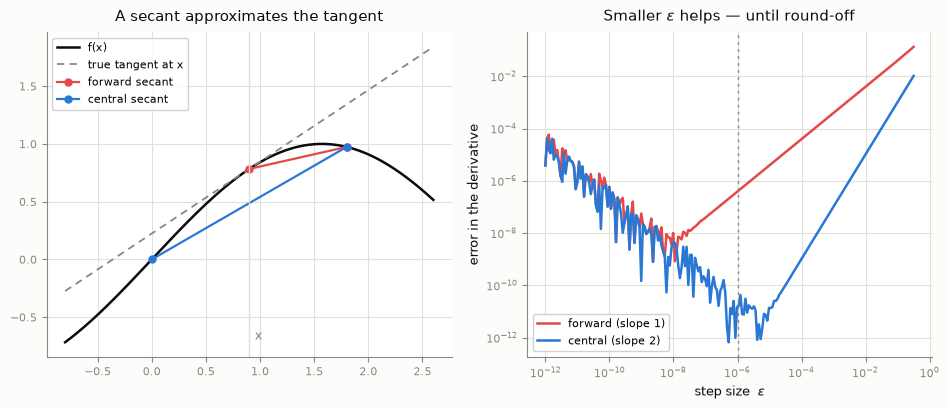

In [10]:
# Finite differences, pictured: a secant slope standing in for the tangent slope,
# and how the approximation error shrinks with the step size epsilon.
f  = lambda x: np.sin(x)            # any smooth function will do
df = lambda x: np.cos(x)            # its exact derivative, for comparison
x0 = 0.9
eps_big = 0.9                       # a deliberately large step, so the secants are visible

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 4.2), facecolor="#fcfcfb")

# --- LEFT: the true tangent vs the forward / central secants -------------------
xs = np.linspace(x0 - 1.7, x0 + 1.7, 300)
axL.plot(xs, f(xs), color=INK, lw=1.8, label="f(x)")
axL.plot(xs, f(x0) + df(x0) * (xs - x0), color=MUTED, lw=1.3, ls=(0, (4, 3)),
         label="true tangent at x")
xp, xm = x0 + eps_big, x0 - eps_big
axL.plot([x0, xp], [f(x0), f(xp)], "-o", color=RED, lw=1.6, ms=5,
         label="forward secant")
axL.plot([xm, xp], [f(xm), f(xp)], "-o", color=BLUE, lw=1.6, ms=5,
         label="central secant")
axL.axvline(x0, color=GRID, lw=1.0)
axL.annotate("x", (x0, f(xs.min())), textcoords="offset points", xytext=(4, 2),
             color=MUTED, fontsize=9)
_style(axL, "A secant approximates the tangent")
axL.legend(loc="upper left", fontsize=8, framealpha=0.9)

# --- RIGHT: approximation error vs step size (log-log) -------------------------
eps = np.logspace(-12, -0.5, 220)
err_fwd = np.abs((f(x0 + eps) - f(x0)) / eps - df(x0))
err_cen = np.abs((f(x0 + eps) - f(x0 - eps)) / (2 * eps) - df(x0))
axR.loglog(eps, err_fwd, color=RED, lw=1.8, label="forward (slope 1)")
axR.loglog(eps, err_cen, color=BLUE, lw=1.8, label="central (slope 2)")
axR.axvline(1e-6, color=MUTED, lw=1.0, ls=(0, (2, 3)))
axR.set_xlabel(r"step size  $\epsilon$", color=INK, fontsize=9)
axR.set_ylabel("error in the derivative", color=INK, fontsize=9)
_style(axR, r"Smaller $\epsilon$ helps — until round-off")
axR.legend(loc="lower left", fontsize=8, framealpha=0.9)

plt.tight_layout(); plt.show()

### 4.2 · Factors that only know how to compute an error

We make factor authoring trivial and impossible to get subtly wrong: a factor defines **only its whitened error**, a vector in the tangent space. The engine obtains the Jacobian by **perturbing each variable along its own retraction** and differencing — the central difference from §4.1, only now *taken through $\boxplus$* (`retract`) instead of by adding to coordinates. This is precisely how GTSAM's tests validate every hand-derived Jacobian, and it means the manifold structure enters in exactly one place (`retract`) instead of being re-derived per factor. §5 then shows the analytic Jacobian for the SE(2) between-factor and checks it against this ground truth.

In [11]:
def numerical_jacobian(error_fn, values, key, dof, eps=1e-6):
    """d(error)/d(tangent perturbation of values[key]), via central differences
    taken *through* the variable's retract -- i.e. the derivative on the manifold."""
    base = values[key]
    cols = []
    for i in range(dof):
        d = np.zeros(dof); d[i] = eps
        vp, vm = dict(values), dict(values)
        vp[key] = base.retract(d)
        vm[key] = base.retract(-d)
        cols.append((error_fn(vp) - error_fn(vm)) / (2 * eps))
    return np.stack(cols, axis=1)

def _W(sigma, dim):
    """Whitening matrix W with W^T W = Sigma^{-1} for a diagonal noise model."""
    sigma = np.asarray(sigma, float)
    if sigma.ndim == 0:
        return np.eye(dim) / sigma
    return np.diag(1.0 / sigma)

class Factor:
    """Base class: define `error(values)` (whitened, tangent-space); the engine
    linearises numerically through each variable's retract."""
    keys, dim = (), 0
    def error(self, values):
        raise NotImplementedError
    def linearize(self, values):
        r = self.error(values)
        blocks = {k: numerical_jacobian(self.error, values, k, values[k].dof)
                  for k in self.keys}
        return r, blocks

class PriorFactor(Factor):
    """Pull a pose toward a measured absolute pose: r = W * log(measured^{-1} X)."""
    def __init__(self, key, measured, sigma):
        self.keys = (key,)
        self.measured = measured
        self.dim = measured.dof
        self.W = _W(sigma, self.dim)
    def error(self, values):
        return self.W @ self.measured.local(values[self.keys[0]])

class BetweenFactor(Factor):
    """Constrain the relative pose X_i^{-1} X_j to a measured value:
       r = W * log( measured^{-1} (X_i^{-1} X_j) )."""
    def __init__(self, k1, k2, measured, sigma):
        self.keys = (k1, k2)
        self.measured = measured
        self.dim = measured.dof
        self.W = _W(sigma, self.dim)
    def error(self, values):
        predicted = values[self.keys[0]].between(values[self.keys[1]])   # X_i^{-1} X_j
        return self.W @ self.measured.local(predicted)

# a between-factor reads zero error when the relative pose matches the measurement
Xi = Pose2(0.0, 0.0, 0.0)
Xj = Pose2(1.0, 0.0, np.deg2rad(20.0))
meas = Xi.between(Xj)
bf = BetweenFactor("i", "j", meas, sigma=[0.1, 0.1, 0.05])
assert np.allclose(bf.error({"i": Xi, "j": Xj}), 0.0, atol=1e-9)
print("between-factor error at the measured relative pose:", np.round(bf.error({"i": Xi, "j": Xj}), 8))

between-factor error at the measured relative pose: [0. 0. 0.]


### 4.3 · The tangent ordering and the solve loop

The engine bookkeeping is the M3 `Ordering`, with one change of meaning: a key's slice now indexes the **tangent** block, sized by the variable's `dof` (3 for `Pose2`, 6 for `Pose3`), not by a stored coordinate count. `solve` stacks the whitened $(r, J)$ exactly as in M3, solves for the tangent increment $\delta$, and applies it with `retract` per variable. The loop stops when $\|\delta\|$ is negligible.

In [12]:
class Ordering:
    """Assign each variable key a contiguous slice of the stacked *tangent* vector."""
    def __init__(self, dofs):                 # dofs: {key: tangent dimension}
        self.slices, i = {}, 0
        for k, d in dofs.items():
            self.slices[k] = slice(i, i + d)
            i += d
        self.n = i

class FactorGraph:
    def __init__(self):
        self.factors = []
    def add(self, factor):
        self.factors.append(factor); return self
    def linearize(self, values, ordering):
        m = sum(f.dim for f in self.factors)
        J = np.zeros((m, ordering.n)); r = np.zeros(m); row = 0
        for f in self.factors:
            r_f, blocks = f.linearize(values)
            r[row:row + f.dim] = r_f
            for key, Jb in blocks.items():
                J[row:row + f.dim, ordering.slices[key]] = Jb
            row += f.dim
        return r, J
    def error(self, values):                  # total 1/2||r||^2, for convergence tracking
        m = sum(f.dim for f in self.factors); r = np.zeros(m); row = 0
        for f in self.factors:
            r[row:row + f.dim] = f.error(values); row += f.dim
        return 0.5 * float(r @ r)
    def solve(self, values, max_iters=25, tol=1e-10):
        """On-manifold Gauss-Newton: solve for a tangent step, retract, repeat."""
        values = dict(values)
        ordering = Ordering({k: v.dof for k, v in values.items()})
        history = [self.error(values)]
        for _ in range(max_iters):
            r, J = self.linearize(values, ordering)
            delta, *_ = np.linalg.lstsq(J, -r, rcond=None)     # J delta = -r
            for k in values:                                   # x <- x boxplus delta
                values[k] = values[k].retract(delta[ordering.slices[k]])
            history.append(self.error(values))
            if np.linalg.norm(delta) < tol:
                break
        return values, history

# smallest possible on-manifold solve: one pose, one prior -> lands on the prior
g = FactorGraph().add(PriorFactor("x", Pose2(1.0, 2.0, np.deg2rad(40.0)), sigma=[0.1, 0.1, 0.1]))
est, hist = g.solve({"x": Pose2(0.0, 0.0, 0.0)})
print("recovered pose:", est["x"], " in", len(hist) - 1, "iterations")
assert np.allclose(est["x"].xytheta(), [1.0, 2.0, np.deg2rad(40.0)], atol=1e-6)

recovered pose: Pose2(x=1.000, y=2.000, theta=40.0deg)  in 3 iterations


## 5 · What a manifold Jacobian actually is

The engine differentiates numerically, which is correct and convenient — but the whole point of Lie groups is that these Jacobians have *clean closed forms*, and understanding them is what lets you read GTSAM, derive custom factors, and reason about a solver's behaviour. So let us derive one by hand and check it.

A manifold Jacobian is the derivative of a **tangent-valued residual** with respect to a **tangent perturbation** of a variable:

$$J_i \;=\; \left.\frac{\partial\, r(X_i \boxplus \xi,\ \dots)}{\partial \xi}\right|_{\xi=0}.$$

Take the between-factor $r = \log\!\big(Z^{-1} X_i^{-1} X_j\big)$ (dropping whitening; it is a constant left-multiply $W$). Perturbing $X_i \to X_i\exp(\xi_i)$ and $X_j \to X_j\exp(\xi_j)$ and keeping first order gives a clean result in terms of the **adjoint** $\mathrm{Ad}_T$ (how a twist transforms when you change frame) and the **right-Jacobian inverse** $J_r^{-1}$ — derived line by line in **Appendix B**:

$$J_j = J_r^{-1}(r)\,,\qquad J_i = -\,J_r^{-1}(r)\,\mathrm{Ad}_{X_j^{-1}X_i}.$$

At the solution — where a good measurement makes the residual small — $J_r^{-1}\to I$ and these collapse to the tidy, memorable forms $J_j \approx I$ and $J_i \approx -\mathrm{Ad}_{X_j^{-1}X_i}$. The cell below builds the SE(2) adjoint, verifies it against its *defining property* $\exp(\mathrm{Ad}_T\,\xi) = T\exp(\xi)T^{-1}$ (an exact group identity), and then confirms these clean small-residual forms match the engine's numerical Jacobians at a near-consistent configuration. (The right Jacobian $J_r$ is what makes them exact for *any* residual, not just near the solution.)

In [13]:
def se2_adjoint(T):
    """Ad_T for SE(2): maps a twist through a change of frame,
       exp(Ad_T xi) == T exp(xi) T^{-1}."""
    R, t = T[:2, :2], T[:2, 2]
    Ad = np.eye(3)
    Ad[:2, :2] = R
    Ad[0, 2] =  t[1]      # [ R | [ y ; -x] ]
    Ad[1, 2] = -t[0]
    return Ad

# verify the adjoint against its defining identity, on a random twist and pose
rng = np.random.default_rng(4)
Ttest = se2_exp(rng.normal(size=3))
xitest = rng.normal(size=3) * 0.3
lhs = se2_exp(se2_adjoint(Ttest) @ xitest)
rhs = Ttest @ se2_exp(xitest) @ np.linalg.inv(Ttest)
assert np.allclose(lhs, rhs, atol=1e-9)
print("adjoint identity  exp(Ad_T xi) = T exp(xi) T^-1  holds:", np.allclose(lhs, rhs))

# --- clean small-residual Jacobians vs the engine's numerical ones -------------
# Pick a measurement Z that is *almost* the true relative pose, so the residual is
# small and the tidy forms  Jj ~ I,  Ji ~ -Ad_{Xj^-1 Xi}  hold to high accuracy.
Xi = Pose2(0.3, -0.4, np.deg2rad(25.0))
Xj = Pose2(1.7,  0.6, np.deg2rad(70.0))
Z  = Xi.between(Xj).retract([0.01, -0.008, 0.006])   # true relative pose, lightly perturbed
bf = BetweenFactor("i", "j", Z, sigma=1.0)
r_num = bf.error({"i": Xi, "j": Xj})
_, blocks = bf.linearize({"i": Xi, "j": Xj})
Ji_num, Jj_num = blocks["i"], blocks["j"]

Adj    = se2_adjoint(Xj.between(Xi).T)               # Ad_{Xj^-1 Xi}
Jj_ana = np.eye(3)
Ji_ana = -Adj
print("residual (small):", np.round(r_num, 4))
print("max |Jj_analytic - Jj_numeric| =", np.max(np.abs(Jj_ana - Jj_num)))
print("max |Ji_analytic - Ji_numeric| =", np.max(np.abs(Ji_ana - Ji_num)))
assert np.max(np.abs(Jj_ana - Jj_num)) < 0.05
assert np.max(np.abs(Ji_ana - Ji_num)) < 0.05

adjoint identity  exp(Ad_T xi) = T exp(xi) T^-1  holds: True
residual (small): [-0.01   0.008 -0.006]
max |Jj_analytic - Jj_numeric| = 0.004996000041619653
max |Ji_analytic - Ji_numeric| = 0.008257641800088478


> **Reading the check.** The adjoint identity holds exactly — that is a property of the group, not an approximation. The between-factor Jacobians match the numerical ground truth because we evaluated at a small residual, where $J_r^{-1}\to I$; feed in a wildly wrong measurement and the gap grows exactly as the omitted $J_r$ terms predict (Appendix B). In practice you never hand-code these unless you are writing a performance-critical custom factor — you let the library (or, here, the numerical differentiator) produce them and you *read* the closed form to understand what the solver is doing. The one non-negotiable idea is that a Jacobian on a manifold is a derivative **through $\boxplus$** — perturb along the retraction, not along the raw coordinates.

## 6 · SE(2) pose-graph optimization: closing a loop

Time to use it. A **pose graph** is the canonical SLAM back-end: the variables are robot poses along a trajectory, the factors are (i) noisy **odometry** between consecutive poses and (ii) **loop closures** — a between-factor added when the robot recognises a place it has visited before. Odometry alone drifts without bound; the loop closure is a single constraint that says "pose $k$ and pose $0$ are actually the same spot," and the optimiser distributes that one piece of information backwards over the whole trajectory.

We drive the robot around a square, corrupt the odometry with noise (so dead-reckoning spirals away from the truth), anchor pose 0 with a prior, and add one loop-closure factor tying the last pose back to the first. Then we solve on the manifold and watch the loop snap shut.

In [14]:
rng = np.random.default_rng(1)

# ground-truth trajectory: a closed square loop. Separate legs keep the corners
# exact -- a forward leg is a pure translation, a corner is a pure in-place turn --
# so the loop returns precisely to the start (position AND heading close).
step, turn = 1.0, np.deg2rad(90.0)
forward, corner = [step, 0.0, 0.0], [0.0, 0.0, turn]
legs = (([forward] * 4) + [corner]) * 4            # 4 sides x (4 steps + 1 turn)
gt = [Pose2(0.0, 0.0, 0.0)]
for xi in legs:
    gt.append(gt[-1].retract(xi))                  # compose the exact odometry leg
K = len(gt)

# noisy odometry measurements + a dead-reckoning trajectory built from them
odo_sigma = np.array([0.02, 0.02, np.deg2rad(1.5)])
dr = [Pose2(0.0, 0.0, 0.0)]
measurements = []
for k in range(K - 1):
    true_rel = gt[k].local(gt[k + 1])              # exact relative twist
    noisy = true_rel + rng.normal(scale=odo_sigma) # corrupt it
    measurements.append(Pose2(T=se2_exp(noisy)))
    dr.append(dr[-1].compose(measurements[-1]))    # dead-reckon: just chain them

# build the graph: prior on pose 0, odometry betweens, one loop closure 15 -> 0
graph = FactorGraph()
graph.add(PriorFactor(0, Pose2(0.0, 0.0, 0.0), sigma=[1e-3, 1e-3, 1e-3]))
for k in range(K - 1):
    graph.add(BetweenFactor(k, k + 1, measurements[k], sigma=odo_sigma))
# loop closure: the robot recognises the start, measuring the last-to-first
# relative pose (here ~identity, since the true loop closes).
graph.add(BetweenFactor(K - 1, 0, gt[K - 1].between(gt[0]), sigma=[0.02, 0.02, np.deg2rad(1.5)]))

# solve on the manifold, initialised from the drifted dead-reckoning
init = {k: dr[k] for k in range(K)}
est, hist = graph.solve(init, max_iters=30)
print(f"Gauss-Newton on the manifold: {len(hist)-1} iterations, "
      f"cost {hist[0]:.3g} -> {hist[-1]:.3g}")

Gauss-Newton on the manifold: 14 iterations, cost 31.8 -> 0.394


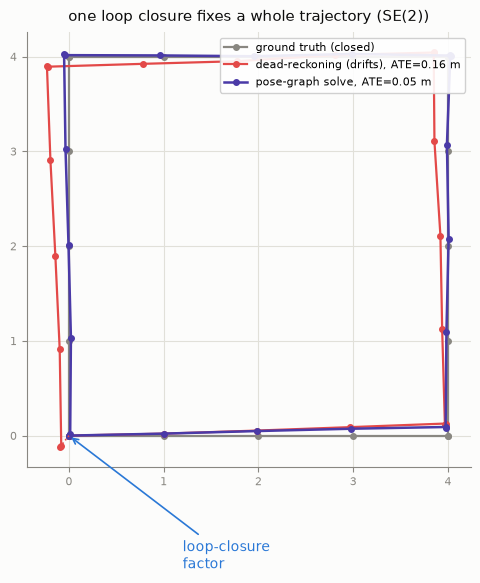

dead-reckoning ATE = 0.165 m   ->   pose-graph ATE = 0.054 m


In [15]:
# how far each trajectory sits from ground truth (position ATE)
def ate(traj):
    return float(np.sqrt(np.mean([(traj[k].xytheta()[:2] - gt[k].xytheta()[:2]) @
                                  (traj[k].xytheta()[:2] - gt[k].xytheta()[:2])
                                  for k in range(K)])))
dr_ate  = ate(dr)
est_ate = ate([est[k] for k in range(K)])

fig, ax = plt.subplots(figsize=(6.4, 6.0), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
G = np.array([p.xytheta()[:2] for p in gt])
D = np.array([p.xytheta()[:2] for p in dr])
E = np.array([est[k].xytheta()[:2] for k in range(K)])
ax.plot(G[:, 0], G[:, 1], "-o", color=MUTED, lw=1.6, ms=4, label="ground truth (closed)")
ax.plot(D[:, 0], D[:, 1], "-o", color=RED, lw=1.6, ms=4, label=f"dead-reckoning (drifts), ATE={dr_ate:.2f} m")
ax.plot(E[:, 0], E[:, 1], "-o", color=VIOLET, lw=1.8, ms=4, label=f"pose-graph solve, ATE={est_ate:.2f} m")
ax.plot([D[-1, 0], D[0, 0]], [D[-1, 1], D[0, 1]], ":", color=RED, lw=1.2)   # the open gap
ax.annotate("loop-closure\nfactor", xy=(E[0, 0], E[0, 1]), xytext=(1.2, -1.4),
            color=BLUE, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.2))
_style(ax, "one loop closure fixes a whole trajectory (SE(2))")
ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

print(f"dead-reckoning ATE = {dr_ate:.3f} m   ->   pose-graph ATE = {est_ate:.3f} m")
assert est_ate < 0.4 * dr_ate      # the solve removes most of the drift

The red path is dead-reckoning: it never returns to the start — the dotted segment is the open gap the drift accumulated. The violet path is the optimised graph: the single loop-closure factor, propagated through every odometry constraint by Gauss–Newton, pulls the whole trajectory back onto the truth and shuts the loop. No angle was ever wrapped by hand; the heading was handled by $SE(2)$'s $\exp/\log$ throughout. This is a real — if tiny — SLAM back-end, and it is the same object GTSAM's `Pose2SLAM` builds.

## 7 · SO(3): rotations in 3-D

Everything above generalises; only the formulas get richer. $SO(3)$ is the group of $3\times3$ rotation matrices ($R^\top R = I,\ \det R = +1$) — a curved **3-dimensional** manifold. Its tangent space $\mathfrak{so}(3)$ is $\mathbb{R}^3$: a rotation-vector $\phi$ whose direction is the axis and whose length is the angle. The bridge is **Rodrigues' formula**.

Write $[\phi]_\times$ for the skew-symmetric "hat" of $\phi$ (the matrix with $[\phi]_\times u = \phi\times u$). Then

$$\exp(\phi) = I + \frac{\sin\theta}{\theta}[\phi]_\times + \frac{1-\cos\theta}{\theta^2}[\phi]_\times^2,\qquad \theta = \|\phi\|,$$

and $\log$ recovers the axis-angle from the antisymmetric part of $R$. These are the exact 3-D analogues of $so2\_exp/so2\_log$; $\boxplus$ and $\boxminus$ are defined the same way, $R\boxplus\phi = R\exp(\phi)$, $S\boxminus R = \log(R^\top S)$. This is what finally replaces the heading hack in full 3-D: there is no angle to wrap because there is no angle — there is a rotation vector, and it is only ever used as a *small local* correction.

In [16]:
def hat(w):
    """so(3): map a 3-vector to its skew-symmetric matrix ( [w]_x u = w x u )."""
    x, y, z = w
    return np.array([[0.0, -z, y], [z, 0.0, -x], [-y, x, 0.0]])

def vee(W):
    return np.array([W[2, 1], W[0, 2], W[1, 0]])

def so3_exp(phi):
    """Rotation-vector -> rotation matrix (Rodrigues)."""
    phi = np.asarray(phi, float)
    th = np.linalg.norm(phi)
    K = hat(phi)
    if th < 1e-8:
        return np.eye(3) + K + 0.5 * K @ K                       # Taylor near 0
    return np.eye(3) + (np.sin(th) / th) * K + ((1 - np.cos(th)) / th**2) * K @ K

def so3_log(R):
    """Rotation matrix -> rotation-vector (axis * angle)."""
    cos_th = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    th = np.arccos(cos_th)
    if th < 1e-8:
        return 0.5 * vee(R - R.T)                                # Taylor near 0
    return (th / (2.0 * np.sin(th))) * vee(R - R.T)

# round-trips and the group law, including a large rotation
phi = np.array([0.3, -1.2, 0.7])
assert np.allclose(so3_log(so3_exp(phi)), phi, atol=1e-9)
R1, R2 = so3_exp([0.2, 0.0, 0.1]), so3_exp([0.0, 0.3, -0.1])
assert np.allclose((R1 @ R2).T @ (R1 @ R2), np.eye(3), atol=1e-12)   # stays a rotation
print("SO(3) exp/log round-trip ok; ||phi - log(exp phi)|| =",
      np.linalg.norm(so3_log(so3_exp(phi)) - phi))

SO(3) exp/log round-trip ok; ||phi - log(exp phi)|| = 2.7194799110210365e-16


## 8 · SE(3): full 6-DOF poses

A pose in space is $SE(3)$: a $4\times4$ homogeneous matrix with an $SO(3)$ rotation and a translation. Its tangent is a 6-vector twist $\xi = (\rho, \phi)$ — three translational, three rotational. Exactly as in the planar case, the translation passes through a **left-Jacobian** $V(\phi)$ that couples it to the rotation:

$$\exp\begin{pmatrix}\rho\\\phi\end{pmatrix} = \begin{bmatrix} \exp(\phi) & V(\phi)\,\rho \\ 0 & 1\end{bmatrix},\qquad V(\phi) = I + \frac{1-\cos\theta}{\theta^2}[\phi]_\times + \frac{\theta-\sin\theta}{\theta^3}[\phi]_\times^2.$$

The `Pose3` type below carries the same interface as `Pose2` — `compose`, `inverse`, `between`, `retract`, `local`, and `dof = 6` — so **every factor and the entire solver from §4 work on it unchanged.** That is the reward for building the engine against the manifold operators instead of against coordinates: going from 3-DOF planar to 6-DOF spatial estimation is a new *type*, not a new solver.

In [17]:
def _V_se3(phi):
    """SE(3) left-Jacobian block; -> I as ||phi|| -> 0."""
    phi = np.asarray(phi, float)
    th = np.linalg.norm(phi)
    K = hat(phi)
    if th < 1e-8:
        return np.eye(3) + 0.5 * K + (1.0 / 6.0) * K @ K
    A = (1 - np.cos(th)) / th**2
    B = (th - np.sin(th)) / th**3
    return np.eye(3) + A * K + B * K @ K

def se3_exp(xi):
    """Twist (rho[3], phi[3]) -> 4x4 SE(3) matrix."""
    rho, phi = np.asarray(xi[:3], float), np.asarray(xi[3:], float)
    T = np.eye(4)
    T[:3, :3] = so3_exp(phi)
    T[:3, 3] = _V_se3(phi) @ rho
    return T

def se3_log(T):
    """4x4 SE(3) matrix -> twist (rho[3], phi[3])."""
    phi = so3_log(T[:3, :3])
    rho = np.linalg.solve(_V_se3(phi), T[:3, 3])
    return np.concatenate([rho, phi])

class Pose3:
    """A spatial rigid pose stored as a 4x4 homogeneous matrix."""
    dof = 6
    def __init__(self, T=None, R=None, t=None):
        if T is not None:
            self.T = np.asarray(T, float)
        else:
            self.T = np.eye(4)
            if R is not None: self.T[:3, :3] = R
            if t is not None: self.T[:3, 3] = t
    @property
    def t(self): return self.T[:3, 3]
    @property
    def R(self): return self.T[:3, :3]
    def compose(self, other): return Pose3(T=self.T @ other.T)
    def inverse(self):        return Pose3(T=np.linalg.inv(self.T))
    def between(self, other): return Pose3(T=np.linalg.inv(self.T) @ other.T)
    def retract(self, xi):    return Pose3(T=self.T @ se3_exp(xi))
    def local(self, other):   return se3_log(np.linalg.inv(self.T) @ other.T)
    def __repr__(self):
        return f"Pose3(t={np.round(self.t,3)}, rot={np.round(so3_log(self.R),3)})"

# round-trips: exp/log, compose/inverse, and boxplus/boxminus, all in 6-DOF
xi = np.array([0.2, -0.3, 0.5, 0.1, -0.4, 0.2])
assert np.allclose(se3_log(se3_exp(xi)), xi, atol=1e-9)
A = Pose3(T=se3_exp([1.0, 2.0, 0.5, 0.2, -0.1, 0.3]))
B = Pose3(T=se3_exp([0.3, -0.7, 1.1, -0.2, 0.4, 0.1]))
assert np.allclose(A.compose(A.between(B)).T, B.T, atol=1e-9)     # A * (A^-1 B) = B
assert np.allclose(A.local(A.retract(xi)), xi, atol=1e-8)         # boxplus/boxminus inverse
print("Pose3 algebra ok:", A)

Pose3 algebra ok: Pose3(t=[0.661 2.05  0.743], rot=[ 0.2 -0.1  0.3])


## 9 · SE(3) pose-graph optimization: a 3-D loop

The same graph, now in space. The robot flies a slanted rectangular loop; odometry is corrupted in all six degrees of freedom; a prior anchors the start and one loop-closure factor ties the end back to it. **We reuse the §4 `FactorGraph`, `PriorFactor`, and `BetweenFactor` with zero changes** — only the variable type is `Pose3`. This is the moment the abstraction pays off.

In [18]:
rng = np.random.default_rng(7)

# ground-truth 3-D loop: a squclaude --resume ffea8cbc-7151-413c-9d19-92ac0316bb11are (forward legs + in-place yaw corners, so it
# closes exactly), then tilted out of the horizontal plane by a fixed world
# rotation -- left-multiplying by a constant cancels in every relative pose, so
# the loop still closes while the poses carry full 3-D roll/pitch/yaw.
def leg(dx, dy, dz, ax, ay, az):
    return np.array([dx, dy, dz, ax, ay, az])
forward = leg(0.6, 0, 0, 0, 0, 0)
corner  = leg(0, 0, 0, 0, 0, np.deg2rad(90))
pattern = (([forward] * 4) + [corner]) * 4
tilt = Pose3(R=so3_exp([0.5, 0.35, 0.0]))          # constant world tilt -> a slanted loop
gt = [tilt]
for xi in pattern:
    gt.append(gt[-1].retract(xi))
K = len(gt)

odo_sigma = np.array([0.03, 0.03, 0.03, np.deg2rad(1.2), np.deg2rad(1.2), np.deg2rad(1.2)])
dr = [gt[0]]                                        # dead-reckon from the true start pose
meas = []
for k in range(K - 1):
    noisy = gt[k].local(gt[k + 1]) + rng.normal(scale=odo_sigma)
    meas.append(Pose3(T=se3_exp(noisy)))
    dr.append(dr[-1].compose(meas[-1]))

graph = FactorGraph()
graph.add(PriorFactor(0, gt[0], sigma=[1e-3] * 6))
for k in range(K - 1):
    graph.add(BetweenFactor(k, k + 1, meas[k], sigma=odo_sigma))
graph.add(BetweenFactor(K - 1, 0, gt[K - 1].between(gt[0]),
                        sigma=[0.03, 0.03, 0.03, np.deg2rad(1.2), np.deg2rad(1.2), np.deg2rad(1.2)]))

est, hist = graph.solve({k: dr[k] for k in range(K)}, max_iters=40)
print(f"SE(3) Gauss-Newton: {len(hist)-1} iterations, cost {hist[0]:.3g} -> {hist[-1]:.3g}")

SE(3) Gauss-Newton: 21 iterations, cost 205 -> 4.66


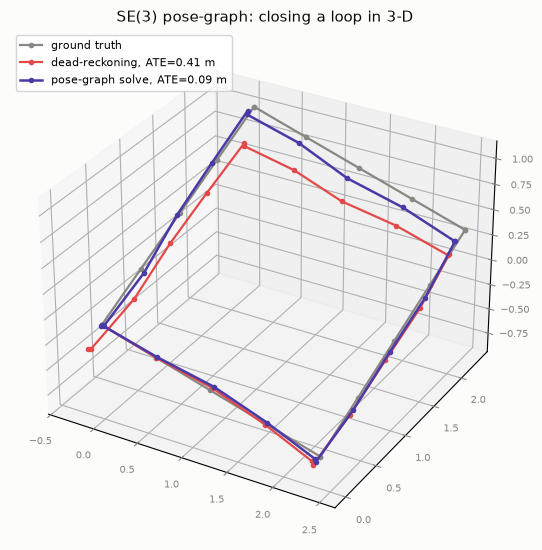

dead-reckoning ATE = 0.410 m   ->   pose-graph ATE = 0.089 m


In [19]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

def ate3(traj):
    return float(np.sqrt(np.mean([np.sum((traj[k].t - gt[k].t) ** 2) for k in range(K)])))
dr_ate, est_ate = ate3(dr), ate3([est[k] for k in range(K)])

G = np.array([p.t for p in gt]); D = np.array([p.t for p in dr])
E = np.array([est[k].t for k in range(K)])
fig = plt.figure(figsize=(6.8, 5.6), facecolor="#fcfcfb")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#fcfcfb")
ax.plot(G[:, 0], G[:, 1], G[:, 2], "-o", color=MUTED, lw=1.6, ms=3, label="ground truth")
ax.plot(D[:, 0], D[:, 1], D[:, 2], "-o", color=RED, lw=1.6, ms=3, label=f"dead-reckoning, ATE={dr_ate:.2f} m")
ax.plot(E[:, 0], E[:, 1], E[:, 2], "-o", color=VIOLET, lw=1.8, ms=3, label=f"pose-graph solve, ATE={est_ate:.2f} m")
ax.set_title("SE(3) pose-graph: closing a loop in 3-D", color=INK, fontsize=11)
ax.legend(loc="upper left", fontsize=8)
ax.tick_params(colors=MUTED, labelsize=7)
for a in (ax.xaxis, ax.yaxis, ax.zaxis):
    a.label.set_color(MUTED)
plt.tight_layout(); plt.show()

print(f"dead-reckoning ATE = {dr_ate:.3f} m   ->   pose-graph ATE = {est_ate:.3f} m")
assert est_ate < 0.5 * dr_ate

## 10 · Tie-back and takeaways

- **The disease was optimising a curved quantity as if it were flat.** Heading angles, rotations, and poses live on Lie groups, not in $\mathbb{R}^n$. The `angular_index` / `wrap_to_pi` hack is a local anaesthetic; Lie theory is the cure, and it removes the hack entirely — we never subtracted or added an angle as a number.
- **The cure is two operators.** $\boxplus$ (retract: $X\exp(\xi)$) and $\boxminus$ (local: $\log(X^{-1}Y)$) are all you bolt onto a Euclidean optimiser. Residuals stay flat (they are $\boxminus$'s), Jacobians are derivatives *through* $\boxplus$, and the only change to Gauss–Newton is $x \leftarrow x \boxplus \delta$ in place of $x \leftarrow x + \delta$.
- **Build against the operators, not the coordinates.** Because `Pose2` and `Pose3` expose the same manifold interface, the *identical* `FactorGraph`, `PriorFactor`, and `BetweenFactor` solved both a planar and a full 6-DOF pose graph. New geometry is a new variable *type*, not a new solver.
- **This is a real SLAM back-end.** A prior + odometry betweens + one loop closure, optimised on the manifold, is exactly the pose-graph problem that GTSAM's `Pose2`/`Pose3` `BetweenFactor`s solve — and what a boat, drone, or legged robot runs to correct drift when it recognises a place.

**Where this goes next.** M5 makes the solve **incremental and sparse** — eliminate variables, keep a running factorisation, and update it as new poses and loop closures arrive instead of re-solving from scratch (the out-of-order-measurement problem, handled natively). M6 maps every object here onto GTSAM one-to-one: `Pose2`/`Pose3`, `BetweenFactor`, noise models, `NonlinearFactorGraph`, `Values`, and `LevenbergMarquardtOptimizer` — you will recognise all of them, because you just built them. M7 puts a real multi-sensor estimator on these rails.

## Appendix A · Where the $V$ matrix comes from

For $SE(2)$, integrating a *constant twist* $(v,\omega)$ for unit time traces the path a robot takes when it translates and rotates simultaneously. The endpoint's rotation is $R(\omega)$, but the translation is **not** $v$ — it is $v$ smeared along a circular arc, which integrates to $V(\omega)\,v$ with

$$V(\omega) = \int_0^1 R(\tau\omega)\,d\tau = \frac{1}{\omega}\begin{bmatrix}\sin\omega & -(1-\cos\omega)\\ 1-\cos\omega & \sin\omega\end{bmatrix}.$$

As $\omega\to0$ the arc straightens, $V\to I$, and $\exp$ reduces to "rotate by $\omega$, translate by $v$" — the naive stacking, which is therefore only correct in the zero-rotation limit. The $SE(3)$ block $V(\phi)$ in §8 is the same integral with $R(\tau\phi)$ the 3-D Rodrigues rotation; its closed form is the one quoted there. The small-angle Taylor guards in `_V_se2` / `_V_se3` avoid the $0/0$ at $\omega=0$.

## Appendix B · Right Jacobian, left Jacobian, and the adjoint

Three matrices recur whenever you differentiate on a Lie group; it is worth naming them.

- **Adjoint $\mathrm{Ad}_T$.** Transforms a twist from one frame to another: $\exp(\mathrm{Ad}_T\,\xi) = T\exp(\xi)\,T^{-1}$. It is how a perturbation on the right of a pose re-expresses as one on the left. We built and tested `se2_adjoint` in §5.
- **Left Jacobian $J_l(\phi) = V(\phi)$.** Relates a perturbation of the tangent vector to the resulting perturbation of $\exp(\phi)$ on the left. It is exactly the $V$ block in $\exp$ — that is not a coincidence.
- **Right Jacobian $J_r(\phi) = J_l(-\phi)$.** The same, for right perturbations (our convention, $X\boxplus\xi = X\exp(\xi)$). It appears in $\boxminus$'s derivative: $\dfrac{\partial}{\partial\xi}\log\!\big(\exp(\phi)\exp(\xi)\big)\big|_0 = J_r(\phi)^{-1}$, which is the $J_r^{-1}(r)$ factor in the between-factor Jacobian of §5.

They satisfy $J_l(\phi) = \mathrm{Ad}_{\exp(\phi)}\,J_r(\phi)$ and all three $\to I$ as $\|\phi\|\to0$ — which is why, at the solution where residuals are small, the factor Jacobians collapse to the clean $J_j\approx I$, $J_i\approx -\mathrm{Ad}$. For SE(2)/SE(3) the closed forms exist (GTSAM implements them); the numerical differentiator in §4 sidesteps needing them while giving the same answer.

**Putting it together — the between-factor Jacobian.** The result quoted in §5 now follows in a few lines. Two facts do all the work:

1. **Right-Jacobian expansion:** $\log\!\big(\exp(a)\exp(b)\big) = a + J_r^{-1}(a)\,b + O(\|b\|^2)$.
2. **Adjoint commutation** (a rearrangement of the defining identity above): $\exp(\eta)\,T = T\,\exp\!\big(\mathrm{Ad}_{T^{-1}}\eta\big)$.

Write the residual as $r = \log\!\big(Z^{-1} X_i^{-1} X_j\big)$, let $r_0$ be its current value, and set $B = X_i^{-1}X_j$ so that $Z^{-1}B = \exp(r_0)$. Perturb one variable at a time along $\boxplus$.

*Perturb $X_j \to X_j\exp(\xi_j)$.* The argument becomes $\exp(r_0)\exp(\xi_j)$, and fact 1 gives $r \approx r_0 + J_r^{-1}(r_0)\,\xi_j$, so

$$J_j = \frac{\partial r}{\partial \xi_j}\Big|_{0} = J_r^{-1}(r_0).$$

*Perturb $X_i \to X_i\exp(\xi_i)$.* Then $X_i^{-1}\to\exp(-\xi_i)X_i^{-1}$, so the argument is $Z^{-1}\exp(-\xi_i)\,B$. Fact 2 slides the perturbation to the right of $B$:

$$\exp(-\xi_i)\,B = B\,\exp\!\big(-\mathrm{Ad}_{B^{-1}}\xi_i\big)\ \Longrightarrow\ Z^{-1}\exp(-\xi_i)\,B = \exp(r_0)\,\exp\!\big(-\mathrm{Ad}_{X_j^{-1}X_i}\,\xi_i\big),$$

using $B^{-1}=X_j^{-1}X_i$. Fact 1 then gives $r \approx r_0 - J_r^{-1}(r_0)\,\mathrm{Ad}_{X_j^{-1}X_i}\,\xi_i$, so

$$J_i = -\,J_r^{-1}(r_0)\,\mathrm{Ad}_{X_j^{-1}X_i}.$$

The adjoint enters at exactly one place: **sliding the $X_i$-perturbation through the relative pose $B=X_i^{-1}X_j$** — which is why the frame that appears is $X_j^{-1}X_i$ and nothing else. At the solution $r_0\to0$, so $J_r^{-1}\to I$ and both collapse to $J_j\approx I$, $J_i\approx-\mathrm{Ad}_{X_j^{-1}X_i}$ — the clean forms checked against the numerical Jacobian in §5.



## Appendix C · Retiring the `angular_index` hack, line by line

The hack maintained a set of state indices that were angles and patched every formula that touched them. Here is the full translation to the manifold view — each patch becomes a call that already lives inside $\exp/\log$:

| `angular_index` hack (flat state) | Manifold replacement |
|---|---|
| keep a list of which state slots are angles | variable *type* knows its own geometry (`Pose2.dof`, `Pose3.dof`) |
| `state += delta` then wrap the angle slots | `x = x.retract(delta)` — wrap is inside `so2_log`/`so3_log`, applied once |
| `innov = z - h(x)`, then `wrap_to_pi(innov)` | `r = measured.local(predicted)` — a $\boxminus$, always the shortest turn |
| special-case the angle rows of the Jacobian | Jacobian is a derivative *through* `retract`; no special case |
| covariance is over $(x,y,\theta)$, wraps ignored | covariance is over the tangent (`dof`-dimensional); no wrap exists there |

The hack is not *wrong* for a single 2-D heading if applied with perfect discipline — it is a hand-rolled, error-prone special case of `so2_log`. The manifold view is the same operation, named once, that also happens to work for $SO(3)$ and $SE(3)$ where "add $2\pi$" has no meaning.

## Appendix D · The numerical Jacobian is the test harness

`numerical_jacobian` is not just a convenience for skipping derivations — it is the *ground truth* you check analytic Jacobians against, and the reason is worth stating. A central difference **through `retract`**,

$$J_{:,i} \approx \frac{r\big(X \boxplus \epsilon e_i\big) - r\big(X \boxminus \epsilon e_i\big)}{2\epsilon},$$

is $O(\epsilon^2)$-accurate and makes no assumption about the group beyond having a correct `retract`. Every hand-derived factor Jacobian in this course (and in GTSAM's test suite) is validated exactly this way. The one subtlety: perturb along $\boxplus$, never along the stored matrix entries — a naive finite difference on the 9 numbers of a rotation matrix leaves the manifold and gives nonsense. Perturbing along the retraction keeps every sample a valid group element, which is the whole discipline of on-manifold optimisation in one line of code.

## Appendix E · What is a group? (and what makes it a *Lie* group)

A refresher for §2, where these two words first do real work.

A **group** is one of the most basic objects in algebra: a set $G$ together with a way to *combine* two of its elements — a binary operation we write "$\cdot$" — obeying four axioms.

| Axiom | Statement | For $SE(2)$ (elements = poses, $\cdot$ = compose) |
|---|---|---|
| **Closure** | $a\cdot b \in G$ for all $a,b\in G$ | composing two poses gives another pose |
| **Associativity** | $(a\cdot b)\cdot c = a\cdot(b\cdot c)$ | chaining motions doesn't depend on the grouping |
| **Identity** | some $e\in G$ has $e\cdot a = a\cdot e = a$ | the "do nothing" pose (the identity matrix) |
| **Inverse** | each $a$ has an $a^{-1}$ with $a\cdot a^{-1}=e$ | every motion can be undone |

That is the entire definition. Note what is *not* required: the operation need not commute. For rotations in 3-D, $a\cdot b \neq b\cdot a$ in general (turn-then-roll $\neq$ roll-then-turn), so $SO(3)$ and $SE(3)$ are **non-commutative** (non-abelian) groups — a fact this module's machinery handles automatically and the naive "stack everything into a vector" approach silently gets wrong.

**Groups you already know.** The integers under $+$ (identity $0$, inverse $-a$); the nonzero reals under $\times$ (identity $1$, inverse $1/a$); and — the one that matters here — $\mathbb{R}^n$ under vector addition, the flat world of M0–M3. The rotations $SO(2)/SO(3)$ and rigid motions $SE(2)/SE(3)$ are groups under composition. That group structure is *why* we can compose odometry, invert a pose, and read a relative pose as $X_i^{-1}X_j$ — those are just the group operations, and they are always exact: no wrap, no approximation.

**What makes it a _Lie_ group.** A **Lie group** is a group that is *also* a smooth manifold, with composition and inversion being smooth (differentiable) maps. That one extra requirement is what unlocks the whole module — you need *both* structures at once:

- because it is a **manifold**, it has a tangent space at every point, so we can do *calculus* — Jacobians, Gauss–Newton, the flat space where we solve;
- because it is a **group**, we can compose and invert, so $\boxplus$, $\boxminus$, and `between` even have meaning.

The tangent space *at the identity* has its own name — the **Lie algebra** ($\mathfrak{so}(2)$, $\mathfrak{se}(3)$, …) — and $\exp$/$\log$ are the bridges between the algebra (flat, where we optimise) and the group (curved, where the estimate lives). In one line: **a Lie group is where algebra and calculus coexist**, which is exactly what on-manifold estimation needs.

$SO(2)$, $SO(3)$, $SE(2)$, $SE(3)$ are all Lie groups. So is $\mathbb{R}^n$ — a *flat* Lie group, where the manifold has no curvature, the Lie algebra is the space itself, and $\boxplus$ collapses back to ordinary $+$. That is the precise sense in which M0–M3 were a special case of this module all along.

## Appendix F · The Lie algebra: why the tangent space is skew-symmetric matrices

This is the full version of the §2.1 aside. The goal is to *derive*, rather than assert, that the tangent space at the identity of a rotation group is the set of **skew-symmetric matrices**, and to see why $\exp$ carries that flat set back onto the curved group.

**1 · What "tangent space at the identity" means.** Take any smooth path of rotations $R(t)$ with $R(0)=I$. Every point on the path is a genuine rotation — the path lives *on* the group. Its velocity at the start, $\dot R(0)$ (differentiate each matrix entry with respect to $t$), is one tangent vector. The **tangent space** is the set of *all* such starting velocities — every direction in which you can leave the identity while staying on the group to first order.

**2 · Differentiate the group constraint.** Every rotation obeys $R(t)^\top R(t) = I$ for all $t$. Differentiate both sides in $t$ (product rule):

$$\dot R(t)^\top R(t) + R(t)^\top \dot R(t) = 0.$$

Evaluate at $t=0$, where $R(0)=I$:

$$\dot R(0)^\top + \dot R(0) = 0 \quad\Longleftrightarrow\quad \dot R(0)^\top = -\,\dot R(0).$$

A matrix equal to minus its own transpose is **skew-symmetric**. So *every* tangent vector at the identity is a skew-symmetric matrix — and conversely every skew-symmetric $\Omega$ is a real tangent, being the velocity of the path $\exp(t\Omega)$. This vector space of skew-symmetric matrices is the **Lie algebra**, written $\mathfrak{so}(n)$.

**3 · Count the free numbers.** A skew-symmetric matrix has zeros on the diagonal and each below-diagonal entry fixed by its mirror, so:

$$\mathfrak{so}(2):\ \begin{bmatrix}0 & -\theta\\ \theta & 0\end{bmatrix}\ \text{— one free number}\ \theta,\qquad \mathfrak{so}(3):\ \begin{bmatrix}0 & -c & b\\ c & 0 & -a\\ -b & a & 0\end{bmatrix}\ \text{— three:}\ (a,b,c).$$

Hence $\mathfrak{so}(2)\cong\mathbb{R}$ (the "real axis" of §2.1) and $\mathfrak{so}(3)\cong\mathbb{R}^3$ (the rotation-vector of §7 — the $3\times3$ pattern is exactly the `hat`/`vee` map). This is why a planar rotation's correction is one number and a spatial rotation's is three.

**4 · $\exp$ really lands back on the group.** The matrix exponential is the same power series as the scalar one, $\exp(\Omega)=I+\Omega+\tfrac{1}{2!}\Omega^2+\tfrac{1}{3!}\Omega^3+\cdots$. Take the $2\times2$ case $\Omega=\theta J$ with $J=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$. Because $J^2=-I$, the powers cycle $J,\,-I,\,-J,\,I,\dots$, so the series splits into the two scalar series for cosine and sine:

$$\exp(\theta J)=\Big(1-\tfrac{\theta^2}{2!}+\tfrac{\theta^4}{4!}-\cdots\Big)I+\Big(\theta-\tfrac{\theta^3}{3!}+\cdots\Big)J=\cos\theta\,I+\sin\theta\,J=\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}=R(\theta).$$

So exponentiating the skew matrix $\theta J$ gives *exactly* the rotation by $\theta$ — the abstract $\exp$ is the `so2_exp` of §2. Running the identical computation with a $3\times3$ skew matrix (now $K^3=-K$) collapses the series to $I+\tfrac{\sin\theta}{\theta}K+\tfrac{1-\cos\theta}{\theta^2}K^2$: **Rodrigues' formula** from §7. Nothing new is needed for 3-D — it is the same series, one dimension up.

**5 · Why we care.** The Lie algebra is a genuine *flat* vector space: skew matrices add and scale like ordinary vectors, so least squares, Jacobians, and Gauss–Newton all make sense there. $\exp/\log$ ferry between that flat space and the curved group, and *every* $\boxplus$/$\boxminus$ in this module is that ferry. Identifying $\mathfrak{so}(2)\cong\mathbb{R}$, $\mathfrak{so}(3)\cong\mathbb{R}^3$, $\mathfrak{se}(2)\cong\mathbb{R}^3$, $\mathfrak{se}(3)\cong\mathbb{R}^6$ is precisely what lets the solver pack a tangent correction into an ordinary coordinate vector and step.